In [ ]:
# !python -m pip install numpy pandas \
#     qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
#     pylatexenc ucimlrepo \
#     xgboost catboost seaborn libsvm-official \
#     jinja2 \
#     scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
import os

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("codes")[0] + "codes"

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [4]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [5]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [ ]:
dataset_path = os.path.join(project_root, "dataset", "Dataset_TehHijau.csv")
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    # 'poly', 
    # 'rbf', 
    # 'sigmoid'
]

In [7]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

In [8]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,1.040900e+04,1.040900e+04,1.040900e+04,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.0,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000
mean,89.414833,47.600730,47.936209,98.291575,89.182246,51.548756,533.670093,213.738592,531.124604,330.500336,48.387732,39.656701,2.935143,34.888942,3.035383,3.135306,3.071880,89.401187,88.072610,90.838121,0.983066,0.031130,-0.497871,797.282995,51.381383,46.428283,86.377366,12.767992,0.047886,-0.767730,461.091603,48.923492,46.665674,56.401095,3.417439,0.042129,-0.742829,435.501633,98.319587,97.190220,99.975002,0.977440,0.153864,-0.336209,872.003728,89.167083,87.839082,90.566625,0.975194,0.054069,-0.778237,790.103132,52.047207,50.200692,56.931309,2.411880,0.011063,-0.779548,460.377366,533.585382,530.475646,535.648189,1.716062,-0.230519,-0.613955,4754.938419,215.542657,212.039427,231.564223,6.549817,-0.059306,-0.657508,1919.990364,531.039823,529.310693,532.089442,1.000540,-0.031123,-0.890127,4742.842444,330.447166,328.831396,331.640503,0.980595,0.022313,-0.777011,2953.280046,4.077809e+03,48.175252,4.034278e+04,1.274229e+04,-2.069636e-02,-0.

Text(0.5, 1.0, 'Histogram for the Kategori')

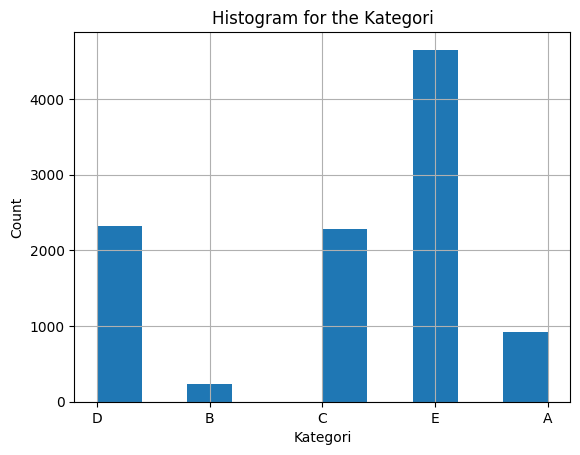

In [9]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [10]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [11]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

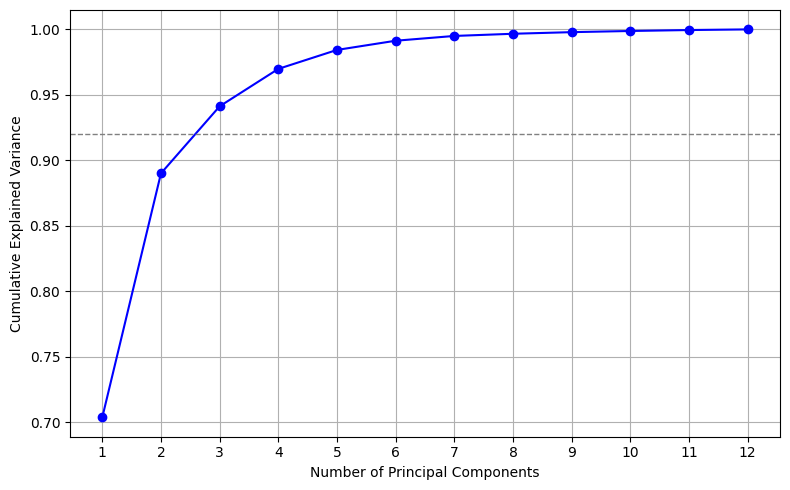

Optimal number of components to retain 92% variance: 3


In [13]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.92)

In [15]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/gs/classical/all")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"{name}.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


# 1. SVC

## 1.1 Linear

In [15]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],
  'class_weight': ['balanced', None],
  'tol': [0.1, 10]
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("svc_linear")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(
        kernel='linear',
        probability=True,
        random_state=42, 
        decision_function_shape='ovr',
        **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

🔬 Search space: 3 C × 2 class_weight × 2 tol =  12 configs × 5 folds = 60 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/12] C=0.1 | class_weight=balanced | tol=0.1
    F1 → Acc=0.3578 | Prec=0.4868 | Rec=0.3578 | F1=0.3368 | AUROC=0.6810 | PRAUC=0.4543
    F2 → Acc=0.3660 | Prec=0.5378 | Rec=0.3660 | F1=0.3506 | AUROC=0.6911 | PRAUC=0.4739
    F3 → Acc=0.3708 | Prec=0.5325 | Rec=0.3708 | F1=0.3571 | AUROC=0.6681 | PRAUC=0.4486
    F4 → Acc=0.3698 | Prec=0.5072 | Rec=0.3698 | F1=0.3482 | AUROC=0.6809 | PRAUC=0.4602
    F5 → Acc=0.3570 | Prec=0.4948 | Rec=0.3570 | F1=0.3301 | AUROC=0.6693 | PRAUC=0.4472
  ✅  Acc:0.3643±0.0058 | Precision:0.5118±0.0202  |Recall:0.3643±0.0058 |F1:0.3446±0.0098 | AUROC:0.6781±0.0085 | PRAUC:0.4568±0.0097 | MCC:0.2221 | Composite:0.4997

  ▶ [2/12] C=0.1 | class_weight=balanced | tol=10
    F1 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.5000 | PRAUC=0.3058
    F2 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AURO

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_linear.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/svc_linear.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = "SVC Linear"
all_best.append(dict(best_result))
log(f"✅ [SVC Linear] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Linear] recorded | Exec. time: 193.4s


## 1.2 Poly

In [19]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],
  'class_weight': ['balanced', None],
  'tol': [0.1, 10],
  'degree': [1, 5],
  'gamma': [0.01, 0.5],
  'coef0': [0, 3],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("svc_poly")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(kernel='poly', probability=True, random_state=42, decision_function_shape='ovr', **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

🔬 Search space: 3 C × 2 class_weight × 2 tol × 2 degree × 2 gamma × 2 coef0 =  96 configs × 5 folds = 480 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/96] C=0.1 | class_weight=balanced | tol=0.1 | degree=1 | gamma=0.01 | coef0=0
    F1 → Acc=0.3420 | Prec=0.4584 | Rec=0.3420 | F1=0.3323 | AUROC=0.6814 | PRAUC=0.4538
    F2 → Acc=0.3362 | Prec=0.4665 | Rec=0.3362 | F1=0.3232 | AUROC=0.6970 | PRAUC=0.4747
    F3 → Acc=0.3242 | Prec=0.4338 | Rec=0.3242 | F1=0.3077 | AUROC=0.6731 | PRAUC=0.4507
    F4 → Acc=0.3473 | Prec=0.4534 | Rec=0.3473 | F1=0.3359 | AUROC=0.6848 | PRAUC=0.4585
    F5 → Acc=0.3417 | Prec=0.4597 | Rec=0.3417 | F1=0.3315 | AUROC=0.6767 | PRAUC=0.4481
  ✅  Acc:0.3383±0.0078 | Precision:0.4544±0.0111  |Recall:0.3383±0.0078 |F1:0.3261±0.0101 | AUROC:0.6826±0.0082 | PRAUC:0.4572±0.0094 | MCC:0.1779 | Composite:0.4927

  ▶ [2/96] C=0.1 | class_weight=balanced | tol=0.1 | degree=1 | gamma=0.01 | coef0=3
    F1 → Acc=0.3410 | Prec=0.4570 | Rec=0.3410 | F1=0

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_poly.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/svc_poly.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = "SVC Poly"
all_best.append(dict(best_result))
log(f"✅ [SVC Poly] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Poly] recorded | Exec. time: 375.2s


## 1.3 RBF

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],
  'class_weight': ['balanced', None],
  'tol': [0.1, 10],
  'gamma': [0.01, 0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("svc_rbf")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  
  
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(kernel='rbf', probability=True, random_state=42, decision_function_shape='ovr', **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

🔬 Search space: 3 C × 2 class_weight × 1 decision_function_shape × 2 tol × 2 gamma =  24 configs × 5 folds = 120 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/24] C=0.1 | class_weight=balanced | decision_function_shape=ovr | tol=0.1 | gamma=0.01

  ▶ C=0.1 | class_weight=balanced | decision_function_shape=ovr | tol=0.1 | gamma=0.01
    F1 → Acc=0.4015 | Prec=0.5112 | Rec=0.4015 | F1=0.3889 | AUROC=0.7404 | PRAUC=0.5151
    F2 → Acc=0.4111 | Prec=0.5491 | Rec=0.4111 | F1=0.3969 | AUROC=0.7556 | PRAUC=0.5459
    F3 → Acc=0.4140 | Prec=0.5307 | Rec=0.4140 | F1=0.3961 | AUROC=0.7319 | PRAUC=0.5172
    F4 → Acc=0.4087 | Prec=0.5396 | Rec=0.4087 | F1=0.3919 | AUROC=0.7381 | PRAUC=0.5270
    F5 → Acc=0.3840 | Prec=0.5124 | Rec=0.3840 | F1=0.3625 | AUROC=0.7279 | PRAUC=0.5079
  ✅  Acc:0.4039±0.0108 | Precision:0.5286±0.0149  |Recall:0.4039±0.0108 |F1:0.3872±0.0127 | AUROC:0.7388±0.0095 | PRAUC:0.5226±0.0131 | MCC:0.2642 | Composite:0.5551

  ▶ [2/24] C=0.1 | class_weight=ba

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/svc_rbf.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = "SVC RBF"
all_best.append(dict(best_result))
log(f"✅ [SVC RBF] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC RBF] recorded | Exec. time: 17.7s


## 1.4 Sigmoid

In [ ]:
# Search Space Configuration
import numpy as np

search_space = {
  'C': [0.1, 1, 10],
  'class_weight': ['balanced', None],
  'tol': [0.1, 10],
  'gamma': [0.01, 0.5],
  'coef0': [0, 3],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
setup_logger("svc_sigmoid")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from utils.hpo import get_search_space
from skopt import BayesSearchCV
from sklearn.decomposition import PCA
from model.models import svc_model
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', SVC(kernel='sigmoid', probability=True, random_state=42, decision_function_shape='ovr', **params))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

     
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

🔬 Search space: 3 C × 2 class_weight × 1 decision_function_shape × 2 tol × 2 gamma × 2 coef0 =  48 configs × 5 folds = 240 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/48] C=0.1 | class_weight=balanced | decision_function_shape=ovr | tol=0.1 | gamma=0.01 | coef0=0

  ▶ C=0.1 | class_weight=balanced | decision_function_shape=ovr | tol=0.1 | gamma=0.01 | coef0=0
    F1 → Acc=0.3420 | Prec=0.4691 | Rec=0.3420 | F1=0.3328 | AUROC=0.6799 | PRAUC=0.4510
    F2 → Acc=0.3319 | Prec=0.4672 | Rec=0.3319 | F1=0.3108 | AUROC=0.6958 | PRAUC=0.4721
    F3 → Acc=0.3256 | Prec=0.4422 | Rec=0.3256 | F1=0.3078 | AUROC=0.6713 | PRAUC=0.4460
    F4 → Acc=0.3439 | Prec=0.4541 | Rec=0.3439 | F1=0.3286 | AUROC=0.6827 | PRAUC=0.4556
    F5 → Acc=0.3378 | Prec=0.4652 | Rec=0.3378 | F1=0.3273 | AUROC=0.6747 | PRAUC=0.4451
  ✅  Acc:0.3362±0.0067 | Precision:0.4596±0.0101  |Recall:0.3362±0.0067 |F1:0.3215±0.0101 | AUROC:0.6809±0.0084 | PRAUC:0.4540±0.0098 | MCC:0.1796 | Composite:0.4904

  ▶ 

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "svc_rbf.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/svc_rbf.csv


In [ ]:
# ── Collect best result ──
best_result['model'] = "SVC Sigmoid"
all_best.append(dict(best_result))
log(f"✅ [SVC Sigmoid] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [SVC Sigmoid] recorded | Exec. time: 69.0s


# 2. XGBoost

## 2.1 GBTree

In [ ]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [100, 500, 1000],
#   'learning_rate': [0.01, 0.5],
#   'max_depth': [4, 7, 10],
#   'subsample': [0.5, 1],
#   'colsample_bytree': [0.5, 1],
# }

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [25]:
setup_logger("xgb_gbtree")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='gbtree', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
log(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\all\xgb_gbtree.log
🕒 Started: 2026-05-22T06:12:21
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth =  8 configs × 5 folds = 40 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/8] n_estimators=100 | learning_rate=0.01 | max_depth=4
    F1 → Acc=0.7118 | Prec=0.7421 | Rec=0.7118 | F1=0.6966 | AUROC=0.9439 | PRAUC=0.8721
    F2 → Acc=0.7176 | Prec=0.7477 | Rec=0.7176 | F1=0.7022 | AUROC=0.9435 | PRAUC=0.8721
    F3 → Acc=0.7094 | Prec=0.7389 | Rec=0.7094 | F1=0.6942 | AUROC=0.9418 | PRAUC=0.8742
    F4 → Acc=0.7214 | Prec=0.7517 | Rec=0.7214 | F1=0.7078 | AUROC=0.9444 | PRAUC=0.8745
    F5 → Acc=0.7371 | Prec=0.7565 | Rec=0.7371 | F1=0.7252 | AUROC=0.9380 | PRAUC=0.8629
  ✅  Acc:0.7195±0.0098 | Precision:0.7474±0.0064  |Recall:0.7195±0.0098 |F1:0.7052±0.0111 | AUROC:0.9423±0.0023 | PRAUC:0.8712±0.0042 | MCC:0.5891 | Composite:0.8443

  ▶ [2/8] n_estimators=100 | learning_rate=0.01 | max_depth=10
    F1 → Acc=0.8948 | Prec=0.8

In [26]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_gbtree.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/xgb_gbtree.csv


In [27]:
# ── Collect best result ──
best_result['model'] = "XGBoost GBTree"
all_best.append(dict(best_result))
log(f"✅ [XGBoost GBTree] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost GBTree] recorded | Exec. time: 15.3s


## 2.2 Dart

In [ ]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'n_estimators': [100, 500, 1000],
#   'learning_rate': [0.01, 0.5],
#   'max_depth': [4, 7, 10],
#   'subsample': [0.5, 1],
#   'colsample_bytree': [0.5, 1],

#   'rate_drop': [0, 0.1, 0.3],
# }

search_space = {
  'n_estimators': [100, 500],
  'learning_rate': [0.01, 0.1],
  'max_depth': [4, 10],

  'rate_drop': [0.1, 0.5],
  'skip_drop': [0.1, 0.5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [29]:
setup_logger("xgb_dart")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()
  
  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('xgb', XGBClassifier(
        booster='dart', objective='multi:softprob', random_state=42, device='cuda', **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
print(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\all\xgb_dart.log
🕒 Started: 2026-05-22T06:15:58
🔬 Search space: 2 n_estimators × 2 learning_rate × 2 max_depth × 2 rate_drop × 2 skip_drop =  32 configs × 5 folds = 160 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/32] n_estimators=100 | learning_rate=0.01 | max_depth=4 | rate_drop=0.1 | skip_drop=0.1
    F1 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.9287 | PRAUC=0.8438
    F2 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.9279 | PRAUC=0.8422
    F3 → Acc=0.4462 | Prec=0.1991 | Rec=0.4462 | F1=0.2753 | AUROC=0.9213 | PRAUC=0.8269
    F4 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.9238 | PRAUC=0.8365
    F5 → Acc=0.4469 | Prec=0.1997 | Rec=0.4469 | F1=0.2761 | AUROC=0.9161 | PRAUC=0.8215
  ✅  Acc:0.4466±0.0002 | Precision:0.1995±0.0002  |Recall:0.4466±0.0002 |F1:0.2758±0.0002 | AUROC:0.9235±0.0046 | PRAUC:0.8342±0.0087 | MCC:0.0000 | Composite:0.7348

  ▶ [2/32] n_estimators=100 | le

In [30]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_dart.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/xgb_dart.csv


In [31]:
# ── Collect best result ──
best_result['model'] = "XGBoost Dart"
all_best.append(dict(best_result))
log(f"✅ [XGBoost Dart] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [XGBoost Dart] recorded | Exec. time: 25.7s


# 3. CatBoost

In [ ]:
# Search Space Configuration
import numpy as np

# search_space = {
#   'iterations': [100, 500, 1000],
#   'depth': [4, 7, 10],
#   'learning_rate': [0.01, 0.5],
#   'l2_leaf_reg': [1, 3, 5],
#   'random_strength': [0.1, 0.5, 1],
# }

search_space = {
  'iterations': [100, 500],
  'depth': [4, 10],
  'learning_rate': [0.01, 0.1],
  'l2_leaf_reg': [1, 5],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [33]:
setup_logger("catboost")
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)
from catboost import CatBoostClassifier

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

log(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
log("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for i, comb in enumerate(product(*param_vals)):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  log(f"\n  ▶ [{i+1}/{total_configs}] {tag}")
  _iter_t0 = time.perf_counter()

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('cat', CatBoostClassifier(
        loss_function="MultiClassOneVsAll",
        eval_metric="Accuracy",
        verbose=0,
        random_seed=42, **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)
    y_prob = y_prob / y_prob.sum(axis=1, keepdims=True)  # Normalize probabilities

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  log(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  iter_time = time.perf_counter() - _iter_t0
  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': f"{roc_mean:.4f}±{roc_std:.4f}",
        'pra': f"{pra_mean:.4f}±{pra_std:.4f}",
        'acc': f"{acc_mean:.4f}±{acc_std:.4f}",
        'f1': f"{f1_mean:.4f}±{f1_std:.4f}",
        'prec': f"{prec_mean:.4f}±{prec_std:.4f}",
        'rec': f"{rec_mean:.4f}±{rec_std:.4f}",
        'params': params,
        'execution_time': iter_time,
    }

log(f"\n🏆 Best config : {best_result['tag']}")
print(
    f"   Composite   : {best_result['composite']} "
    f"(AUROC={best_result['roc']} | "
    f"PRAUC={best_result['pra']} | "
    f"Acc={best_result['acc']} |"
    f"Prec={best_result['prec']} |"
    f"Rec={best_result['rec']}) |"
)

📝 Log: results\logs\gs\classical\all\catboost.log
🕒 Started: 2026-05-22T07:42:30
🔬 Search space: 2 iterations × 2 depth × 2 learning_rate × 2 l2_leaf_reg =  16 configs × 5 folds = 80 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ [1/16] iterations=100 | depth=4 | learning_rate=0.01 | l2_leaf_reg=1
    F1 → Acc=0.6796 | Prec=0.6854 | Rec=0.6796 | F1=0.6471 | AUROC=0.8948 | PRAUC=0.7722
    F2 → Acc=0.6782 | Prec=0.6834 | Rec=0.6782 | F1=0.6435 | AUROC=0.9001 | PRAUC=0.7770
    F3 → Acc=0.6724 | Prec=0.6766 | Rec=0.6724 | F1=0.6345 | AUROC=0.9071 | PRAUC=0.7872
    F4 → Acc=0.6820 | Prec=0.6899 | Rec=0.6820 | F1=0.6479 | AUROC=0.9034 | PRAUC=0.7800
    F5 → Acc=0.6776 | Prec=0.6831 | Rec=0.6776 | F1=0.6468 | AUROC=0.9000 | PRAUC=0.7829
  ✅  Acc:0.6780±0.0032 | Precision:0.6837±0.0043  |Recall:0.6780±0.0032 |F1:0.6440±0.0050 | AUROC:0.9011±0.0041 | PRAUC:0.7799±0.0051 | MCC:0.5178 | Composite:0.7863

  ▶ [2/16] iterations=100 | depth=4 | learning_rate=0.01 | l2_leaf_reg=5


In [34]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "catboost.csv"
df.to_csv(filename, index=False)

log(f"✅ Saved: {filename}")

✅ Saved: ./results/catboost.csv


In [35]:
# ── Collect best result ──
best_result['model'] = "CatBoost"
all_best.append(dict(best_result))
log(f"✅ [CatBoost] recorded | Exec. time: {best_result['execution_time']:.1f}s")

✅ [CatBoost] recorded | Exec. time: 198.2s


---
## 📊 Tabel Evaluasi Akhir

In [36]:
# ════════════════════════════════════════════════════════════
# 📊 TABEL EVALUASI AKHIR – Classical Models
# ════════════════════════════════════════════════════════════
import pandas as pd

def build_eval_table(all_best):
    rows = []
    for r in all_best:
        params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
        rows.append({
            'Model'          : r['model'],
            'Accuracy'       : r['acc'],
            'Precision'      : r['prec'],
            'Recall'         : r['rec'],
            'F1-Score'       : r['f1'],
            'ROC-AUC'        : r['roc'],
            'PR-AUC'         : r['pra'],
            'Exec. Time (s)' : round(r['execution_time'], 2) if 'execution_time' in r else 'N/A',
            'Best Params'    : params_str,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
    df.index += 1
    return df

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)

eval_df = build_eval_table(all_best)
display(eval_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Exec. Time (s),Best Params
1,XGBoost GBTree,0.9189±0.0065,0.9195±0.0066,0.9189±0.0065,0.9191±0.0065,0.9917±0.0011,0.9767±0.0035,134.8300,n_estimators=1000 | learning_rate=0.01 | max_depth=10 | subsample=0.5 | colsample_bytree=1
2,CatBoost,0.9193±0.0037,0.9197±0.0038,0.9193±0.0037,0.9194±0.0037,0.9915±0.0009,0.9766±0.0027,198.2000,iterations=500 | depth=10 | learning_rate=0.1 | l2_leaf_reg=1
3,XGBoost GBTree,0.9136±0.0072,0.9143±0.0074,0.9136±0.0072,0.9138±0.0072,0.9912±0.0012,0.9756±0.0036,15.3000,n_estimators=100 | learning_rate=0.1 | max_depth=10
4,XGBoost Dart,0.9145±0.0083,0.9151±0.0086,0.9145±0.0083,0.9146±0.0084,0.9908±0.0012,0.9748±0.0037,25.6900,n_estimators=100 | learning_rate=0.1 | max_depth=10 | rate_drop=0.1 | skip_drop=0.5


CatBoost terakhir dengan waktu eksekusi 168.8900 merupakan `loss_function="Multiclass"`, sedangkan dua sisanya adalah `loss_function="MulticlassOneVsAll"`

In [56]:
import os
os.makedirs('./results', exist_ok=True)
eval_df.to_csv('./results/eval_classical_final.csv', index=True)
print('✅ Saved: ./results/eval_classical_final.csv')

✅ Saved: ./results/eval_classical_final.csv
